# VISUALIZACIÓN DE DATOS CON MATPLOTLIB Y SEABORN
## Elias Buitrago Bolivar
###

En este cuaderno de jupyter se construyen gráficos con matplotlib y con seaborn. La idea que ordena todo el recorrido es que el gráfico no se elige por bonito sino por la pregunta que responde.

### Origen de los datos

Supermarket Sales, publicado en Kaggle por Aung Pyae.

Página del conjunto: https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales

Archivo de descarga directa (no requiere credenciales de Kaggle): https://raw.githubusercontent.com/plotly/datasets/master/supermarket_Sales.csv

Es el mismo conjunto del cuaderno 01: 1000 registros de tres sucursales durante tres meses de 2019. Se usa a propósito una base ya conocida y limpia, para que toda la atención esté en el gráfico y no en los datos.

### Importar librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar y preparar los datos

Estas celdas repiten lo que ya se hizo en el cuaderno 01. Se ejecutan de corrido para tener la tabla lista.

In [ ]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/supermarket_Sales.csv'
data = pd.read_csv(url)
data.shape

(1000, 17)

In [ ]:
data = data.rename(columns={'Tax 5%': 'Tax',
                            'Cost of goods sold': 'Cogs',
                            'Gross margin percentage': 'Gross margin pct',
                            'Customer stratification rating': 'Rating'})

data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
data.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender',
       'product_line', 'unit_price', 'quantity', 'tax', 'total', 'date',
       'time', 'payment', 'cogs', 'gross_margin_pct', 'gross_income',
       'rating'],
      dtype='object')

In [ ]:
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y')
data['mes'] = data['date'].dt.month
data['dia_semana'] = data['date'].dt.day_name()
data['hora'] = pd.to_datetime(data['time'], format='%H:%M').dt.hour
data.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax,total,date,time,payment,cogs,gross_margin_pct,gross_income,rating,mes,dia_semana,hora
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,1,Saturday,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,3,Friday,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,3,Sunday,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,1,Sunday,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,2,Friday,10


## LA FIGURA Y LOS EJES

Todo gráfico de matplotlib vive dentro de dos objetos: la figura, que es el lienzo, y el eje, que es el área donde se dibuja. Conviene crearlos de forma explícita en lugar de dejar que matplotlib los invente.

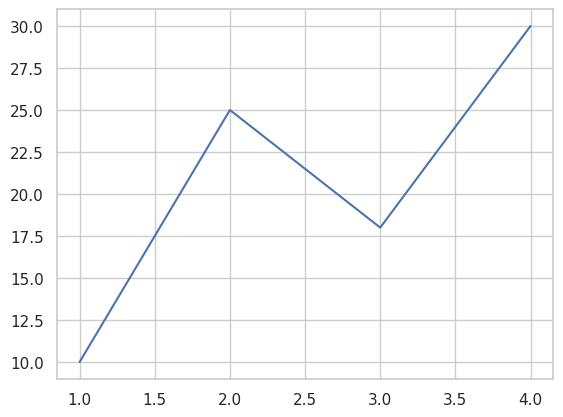

In [ ]:
# La forma corta: matplotlib crea la figura y el eje por detrás
plt.plot([1, 2, 3, 4], [10, 25, 18, 30])
plt.show()

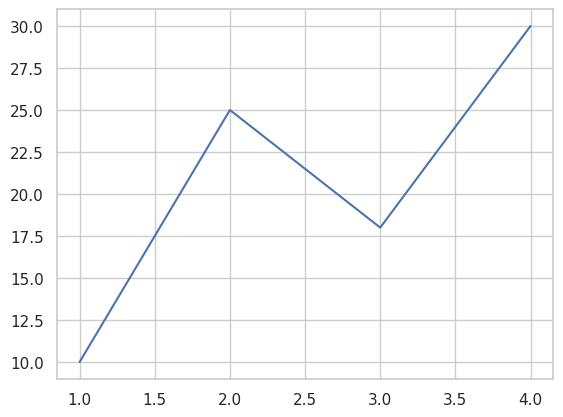

In [ ]:
# La forma explícita: primero se crean figura y eje, después se dibuja sobre el eje
figura, eje = plt.subplots()
eje.plot([1, 2, 3, 4], [10, 25, 18, 30])
plt.show()

Las dos líneas producen el mismo dibujo. La segunda es la que conviene aprender: cuando haya que poner dos gráficos en la misma figura, o ajustar un eje y no el otro, la forma corta se queda sin camino.

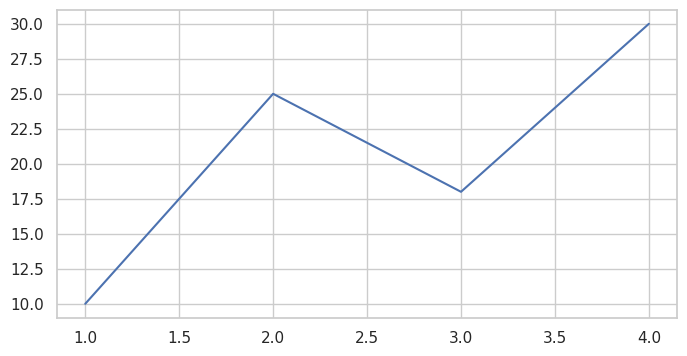

In [ ]:
# figsize se da en pulgadas, ancho por alto
figura, eje = plt.subplots(figsize=(8, 4))
eje.plot([1, 2, 3, 4], [10, 25, 18, 30])
plt.show()

### Un gráfico sin título no dice nada

In [ ]:
ingreso_mes = data.groupby('mes')['total'].sum()
ingreso_mes

,total
mes,
1,116291.868
2,97219.374
3,109455.507


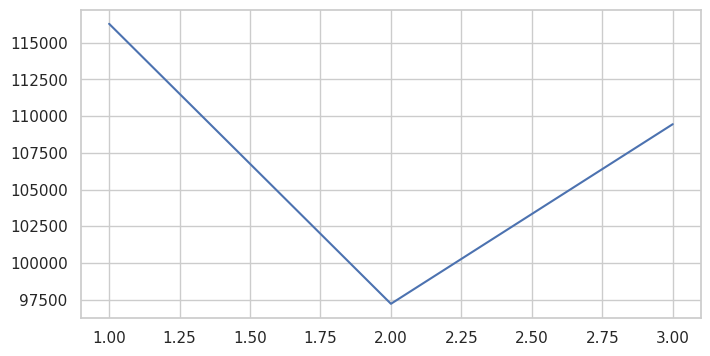

In [ ]:
# Sin rótulos: el lector no sabe qué está viendo
figura, eje = plt.subplots(figsize=(8, 4))
eje.plot(ingreso_mes.index, ingreso_mes.values)
plt.show()

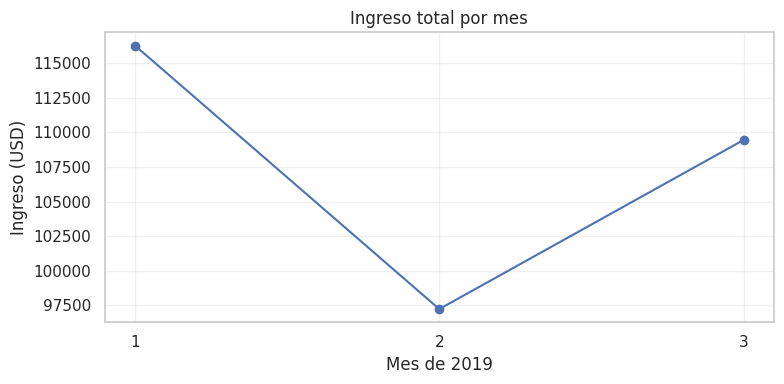

In [ ]:
# Con rótulos: el gráfico se explica solo
figura, eje = plt.subplots(figsize=(8, 4))
eje.plot(ingreso_mes.index, ingreso_mes.values, marker='o')
eje.set_title('Ingreso total por mes')
eje.set_xlabel('Mes de 2019')
eje.set_ylabel('Ingreso (USD)')
eje.set_xticks([1, 2, 3])
eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cuatro instrucciones convierten un dibujo en un gráfico: el título dice qué se está mirando, los nombres de los ejes dicen en qué unidades, y la rejilla ayuda a leer valores intermedios. tight_layout evita que los rótulos queden cortados.

### Guardar la figura

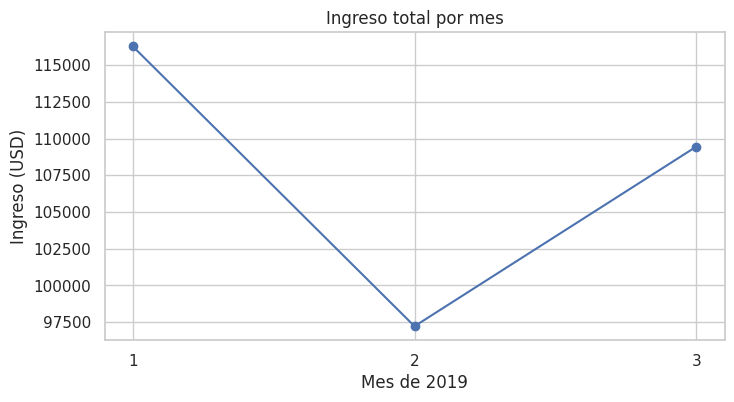

In [ ]:
figura, eje = plt.subplots(figsize=(8, 4))
eje.plot(ingreso_mes.index, ingreso_mes.values, marker='o')
eje.set_title('Ingreso total por mes')
eje.set_xlabel('Mes de 2019')
eje.set_ylabel('Ingreso (USD)')
eje.set_xticks([1, 2, 3])

# dpi controla la resolución y bbox_inches evita que se corten los rótulos
figura.savefig('ingreso_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()

## ELEGIR EL GRÁFICO SEGÚN LA PREGUNTA

No hay gráficos buenos y malos: hay gráficos que responden la pregunta y gráficos que no. Cuatro preguntas cubren casi todo el trabajo cotidiano.

### Comparar categorías: barras

Pregunta: ¿cuál línea de producto vende más?

In [ ]:
ingreso_linea = data.groupby('product_line')['total'].sum().sort_values()
ingreso_linea

,total
product_line,
Health and beauty,49193.7390
Home and lifestyle,53861.9130
Fashion accessories,54305.8950
Electronic accessories,54337.5315
Sports and travel,55122.8265
Food and beverages,56144.8440


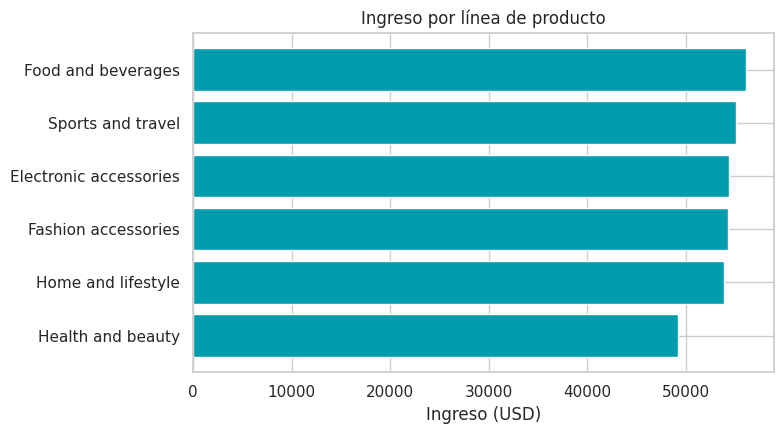

In [ ]:
# Barras horizontales: los nombres largos se leen sin girar la cabeza
figura, eje = plt.subplots(figsize=(8, 4.5))
eje.barh(ingreso_linea.index, ingreso_linea.values, color='#009DAE')
eje.set_title('Ingreso por línea de producto')
eje.set_xlabel('Ingreso (USD)')
plt.tight_layout()
plt.show()

Dos decisiones detrás de este gráfico. Se ordenó de menor a mayor, porque unas barras ordenadas dejan ver la jerarquía sin obligar a comparar longitudes una por una. Y se usaron barras horizontales, porque los nombres de las líneas de producto son largos y en vertical quedarían girados.

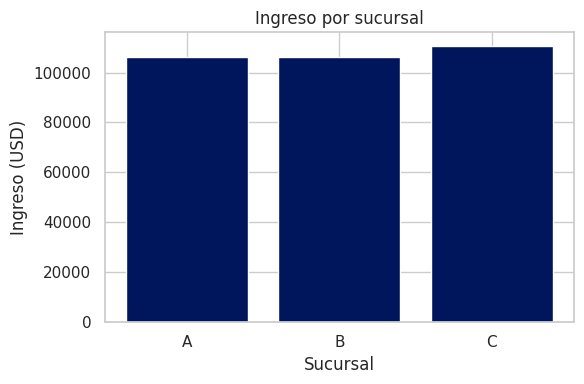

In [ ]:
# Barras verticales cuando las etiquetas son cortas
ingreso_sucursal = data.groupby('branch')['total'].sum()

figura, eje = plt.subplots(figsize=(6, 4))
eje.bar(ingreso_sucursal.index, ingreso_sucursal.values, color='#00165C')
eje.set_title('Ingreso por sucursal')
eje.set_xlabel('Sucursal')
eje.set_ylabel('Ingreso (USD)')
plt.tight_layout()
plt.show()

### Evolución en el tiempo: líneas

Pregunta: ¿cómo se comportó la venta día a día?

In [ ]:
ingreso_dia = data.groupby('date')['total'].sum()
ingreso_dia.head()

,total
date,
2019-01-01,4745.1810
2019-01-02,1945.5030
2019-01-03,2078.1285
2019-01-04,1623.6885
2019-01-05,3536.6835


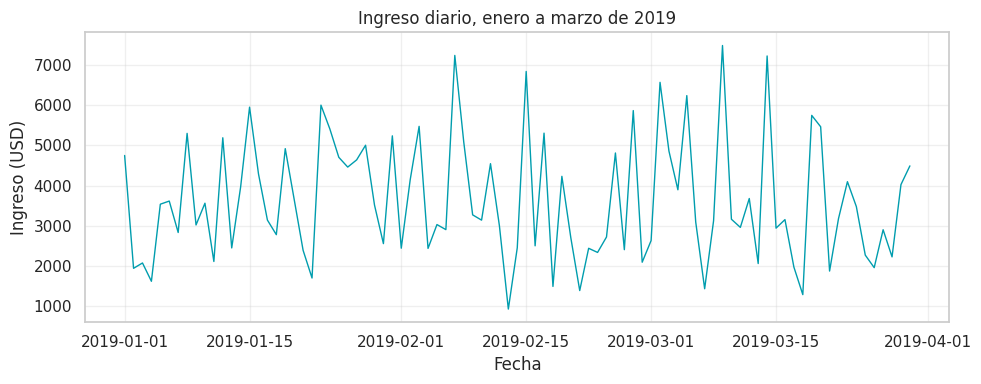

In [ ]:
figura, eje = plt.subplots(figsize=(10, 4))
eje.plot(ingreso_dia.index, ingreso_dia.values, linewidth=1, color='#009DAE')
eje.set_title('Ingreso diario, enero a marzo de 2019')
eje.set_xlabel('Fecha')
eje.set_ylabel('Ingreso (USD)')
eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

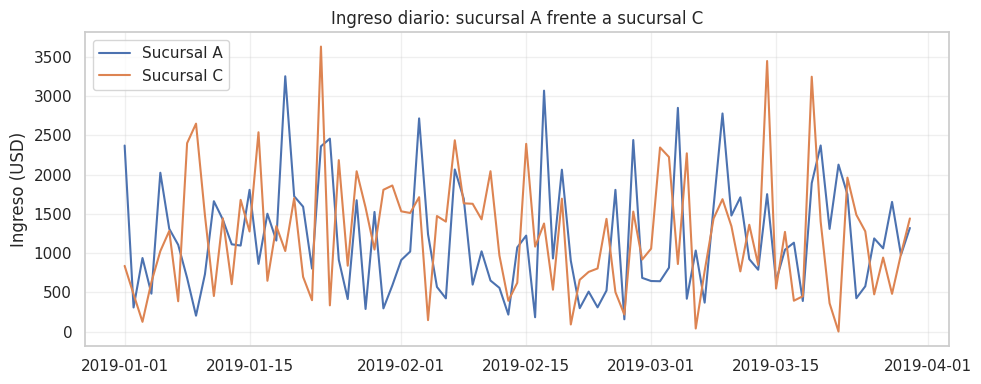

In [ ]:
# Dos series en el mismo eje se comparan mejor que dos gráficos separados
por_dia_sucursal = data.pivot_table(index='date', columns='branch',
                                    values='total', aggfunc='sum', fill_value=0)

figura, eje = plt.subplots(figsize=(10, 4))
eje.plot(por_dia_sucursal.index, por_dia_sucursal['A'], label='Sucursal A')
eje.plot(por_dia_sucursal.index, por_dia_sucursal['C'], label='Sucursal C')
eje.set_title('Ingreso diario: sucursal A frente a sucursal C')
eje.set_ylabel('Ingreso (USD)')
eje.legend()
eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Relación entre dos variables: dispersión

Pregunta: ¿las ventas de mayor valor reciben mejor calificación?

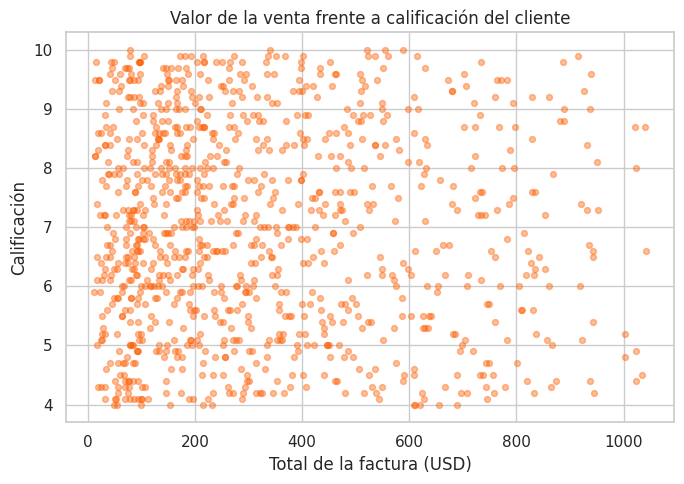

In [ ]:
figura, eje = plt.subplots(figsize=(7, 5))
eje.scatter(data['total'], data['rating'], alpha=0.4, s=18, color='#FD5D00')
eje.set_title('Valor de la venta frente a calificación del cliente')
eje.set_xlabel('Total de la factura (USD)')
eje.set_ylabel('Calificación')
plt.tight_layout()
plt.show()

In [ ]:
# El gráfico sugiere que no hay relación. El coeficiente lo confirma
round(data['total'].corr(data['rating']), 4)

np.float64(-0.0364)

Este es un resultado válido y vale la pena decirlo en clase: un gráfico que muestra que no hay relación es tan útil como uno que la muestra. Lo que no se puede hacer es dibujar una tendencia donde no la hay.

### Distribución: histograma y caja

Pregunta: ¿cómo se reparten los valores de las facturas?

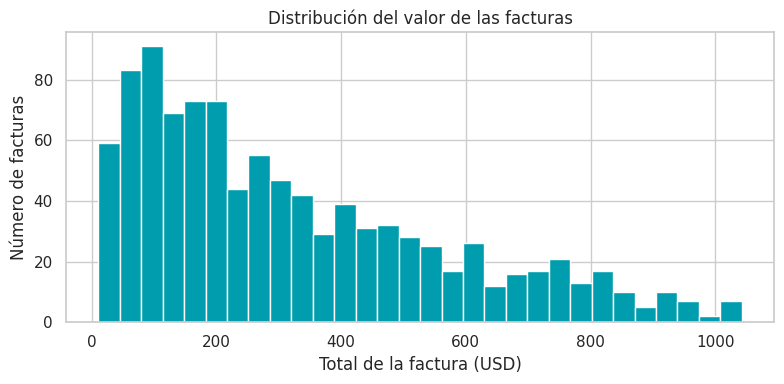

In [ ]:
figura, eje = plt.subplots(figsize=(8, 4))
eje.hist(data['total'], bins=30, color='#009DAE', edgecolor='white')
eje.set_title('Distribución del valor de las facturas')
eje.set_xlabel('Total de la factura (USD)')
eje.set_ylabel('Número de facturas')
plt.tight_layout()
plt.show()

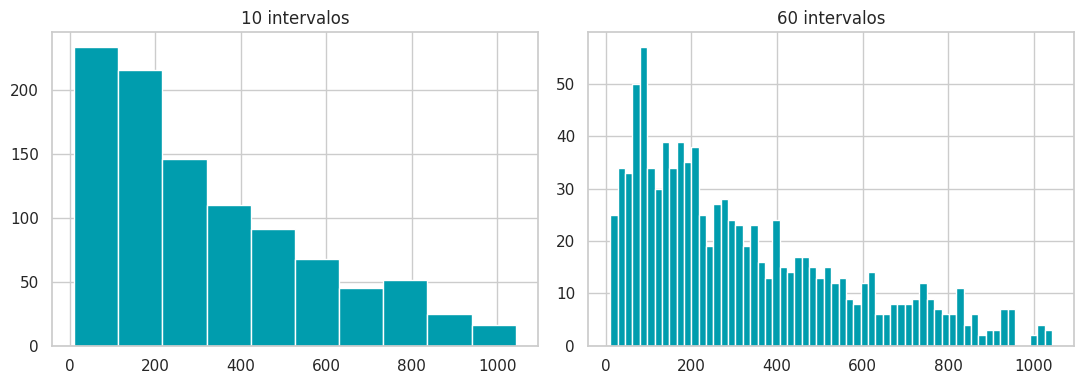

In [ ]:
# El número de barras cambia la lectura: conviene probar más de uno
figura, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].hist(data['total'], bins=10, color='#009DAE', edgecolor='white')
ejes[0].set_title('10 intervalos')
ejes[1].hist(data['total'], bins=60, color='#009DAE', edgecolor='white')
ejes[1].set_title('60 intervalos')
plt.tight_layout()
plt.show()

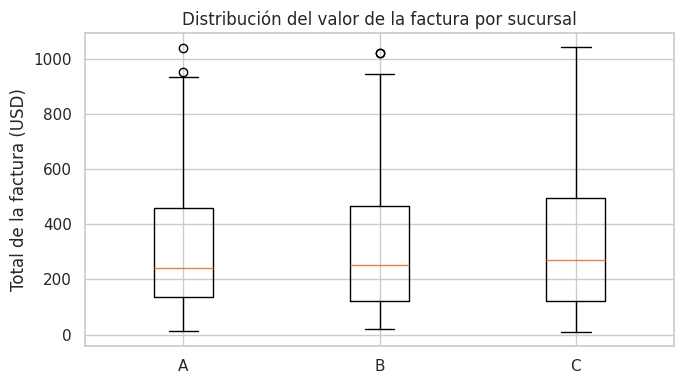

In [ ]:
# La caja resume la distribución en cinco números y deja ver los extremos
figura, eje = plt.subplots(figsize=(7, 4))
eje.boxplot([data.loc[data['branch'] == b, 'total'] for b in ['A', 'B', 'C']],
            tick_labels=['A', 'B', 'C'])
eje.set_title('Distribución del valor de la factura por sucursal')
eje.set_ylabel('Total de la factura (USD)')
plt.tight_layout()
plt.show()

## VARIOS EJES EN UNA FIGURA

subplots devuelve una figura y un arreglo de ejes. Cada eje se dibuja por separado.

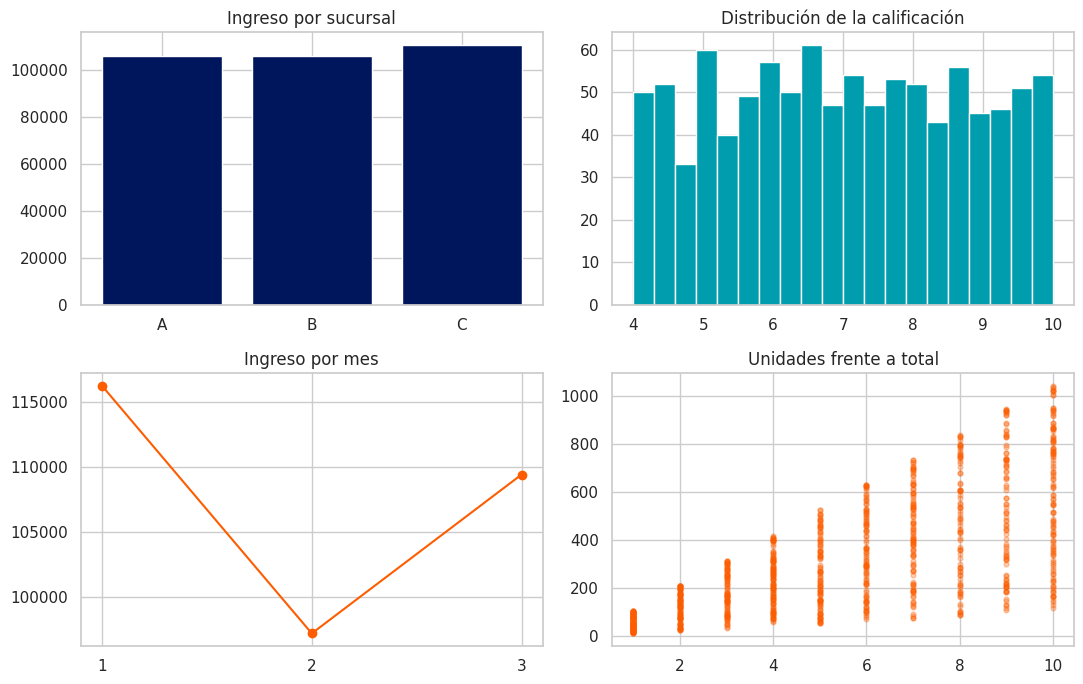

In [ ]:
figura, ejes = plt.subplots(2, 2, figsize=(11, 7))

ejes[0, 0].bar(ingreso_sucursal.index, ingreso_sucursal.values, color='#00165C')
ejes[0, 0].set_title('Ingreso por sucursal')

ejes[0, 1].hist(data['rating'], bins=20, color='#009DAE', edgecolor='white')
ejes[0, 1].set_title('Distribución de la calificación')

ejes[1, 0].plot(ingreso_mes.index, ingreso_mes.values, marker='o', color='#FD5D00')
ejes[1, 0].set_title('Ingreso por mes')
ejes[1, 0].set_xticks([1, 2, 3])

ejes[1, 1].scatter(data['quantity'], data['total'], alpha=0.3, s=12, color='#FD5D00')
ejes[1, 1].set_title('Unidades frente a total')

plt.tight_layout()
plt.show()

El arreglo de ejes se recorre con dos índices: fila y columna. Con una sola fila, ejes es unidimensional y basta un índice.

## EL ATAJO DE PANDAS

Cualquier Series o DataFrame sabe dibujarse a sí mismo. Es la vía rápida para mirar algo durante el análisis.

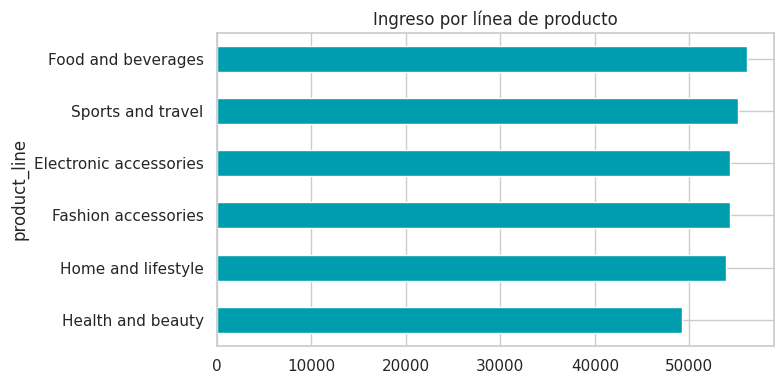

In [ ]:
ingreso_linea.plot(kind='barh', figsize=(8, 4), color='#009DAE')
plt.title('Ingreso por línea de producto')
plt.tight_layout()
plt.show()

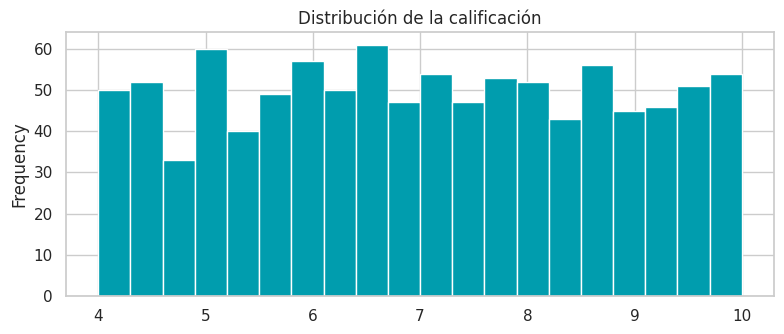

In [ ]:
data['rating'].plot(kind='hist', bins=20, figsize=(8, 3.5), color='#009DAE')
plt.title('Distribución de la calificación')
plt.tight_layout()
plt.show()

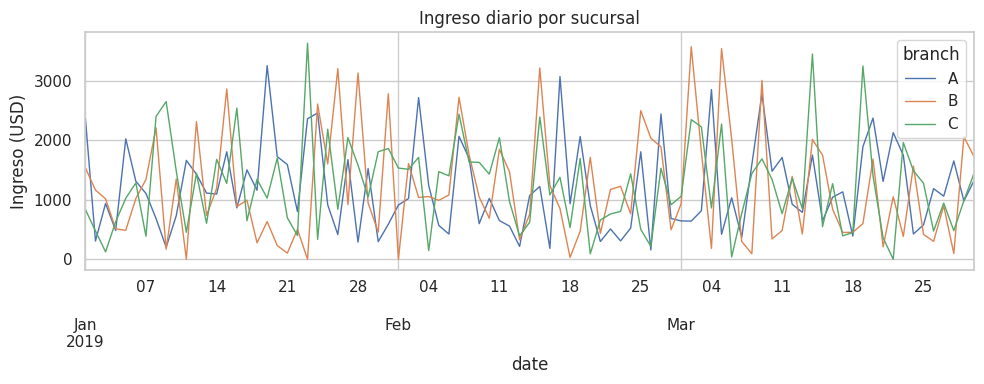

In [ ]:
# plot devuelve un eje, así que se puede seguir ajustando como cualquier otro
eje = por_dia_sucursal.plot(figsize=(10, 4), linewidth=1)
eje.set_title('Ingreso diario por sucursal')
eje.set_ylabel('Ingreso (USD)')
plt.tight_layout()
plt.show()

El atajo sirve para explorar. Para un gráfico que va a salir en un informe conviene volver a plt.subplots, porque da control sobre cada detalle.

## SEABORN

Seaborn se apoya en matplotlib y le agrega tres cosas: entiende un DataFrame directamente, calcula agregaciones por su cuenta y separa por una tercera variable con el argumento hue.

In [ ]:
# El estilo se fija una vez y aplica a todos los gráficos siguientes
sns.set_theme(style='whitegrid', palette='deep')

### Contar categorías

countplot cuenta las filas de cada categoría. No hay que agrupar antes.

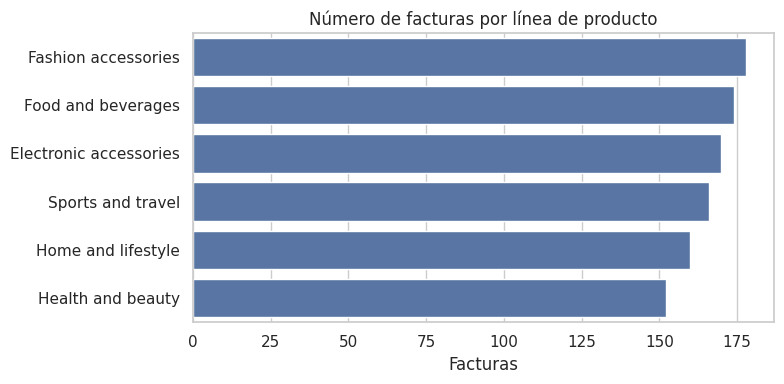

In [ ]:
figura, eje = plt.subplots(figsize=(8, 4))
# order aplica la misma regla del gráfico de barras: ordenar por valor, no por aparición
orden = data['product_line'].value_counts().index
sns.countplot(data=data, y='product_line', order=orden, ax=eje)
eje.set_title('Número de facturas por línea de producto')
eje.set_xlabel('Facturas')
eje.set_ylabel('')
plt.tight_layout()
plt.show()

### Comparar promedios

barplot calcula el promedio de cada grupo y dibuja además la barra de error. Ese detalle importa: dice cuánta incertidumbre hay detrás del promedio.

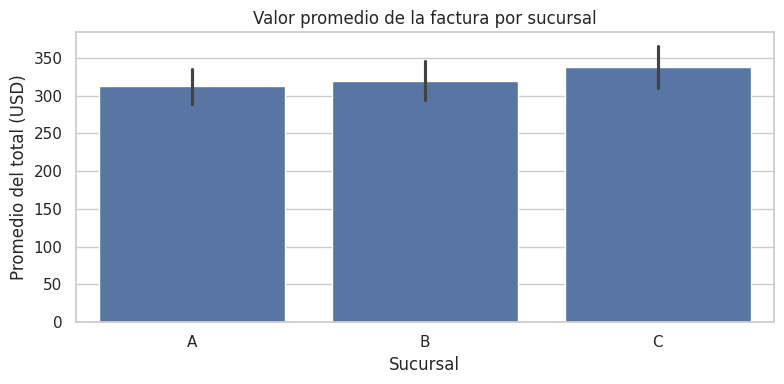

In [ ]:
figura, eje = plt.subplots(figsize=(8, 4))
sns.barplot(data=data, x='branch', y='total', order=['A', 'B', 'C'], ax=eje)
eje.set_title('Valor promedio de la factura por sucursal')
eje.set_xlabel('Sucursal')
eje.set_ylabel('Promedio del total (USD)')
plt.tight_layout()
plt.show()

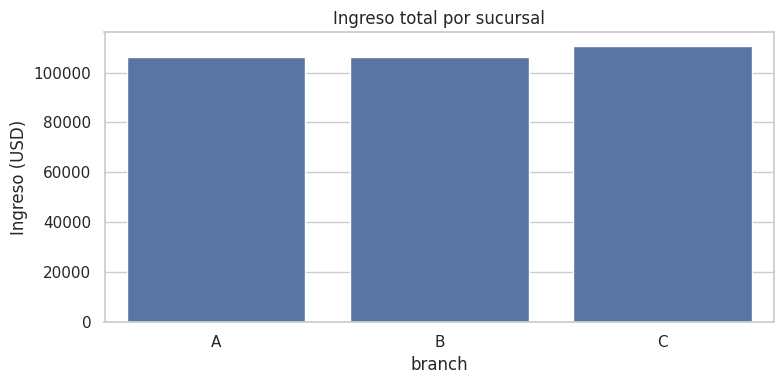

In [ ]:
# estimator cambia la operación: aquí la suma en lugar del promedio
figura, eje = plt.subplots(figsize=(8, 4))
sns.barplot(data=data, x='branch', y='total', estimator='sum',
            errorbar=None, order=['A', 'B', 'C'], ax=eje)
eje.set_title('Ingreso total por sucursal')
eje.set_ylabel('Ingreso (USD)')
plt.tight_layout()
plt.show()

Las barras de error del gráfico anterior se solapan por completo entre las tres sucursales. La lectura correcta es que no hay evidencia de que una sucursal venda tickets más altos que otra.

### Separar por una tercera variable

hue es lo que más se agradece de seaborn: divide cualquier gráfico por una variable categórica sin escribir un ciclo.

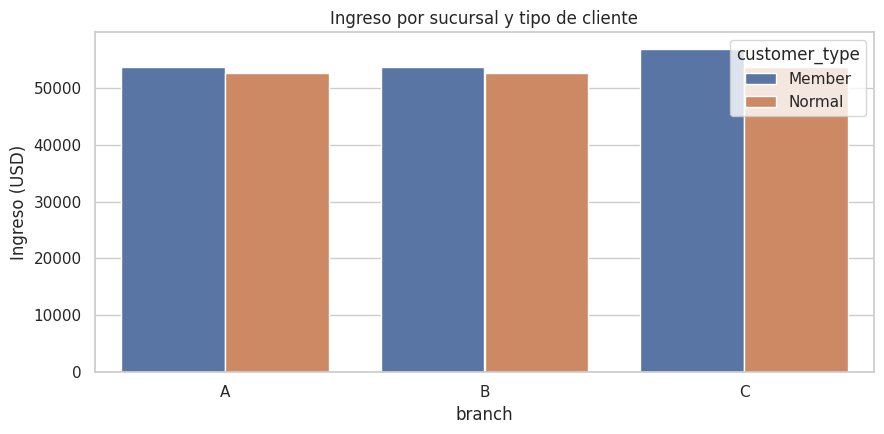

In [ ]:
figura, eje = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=data, x='branch', y='total', hue='customer_type',
            estimator='sum', errorbar=None, order=['A', 'B', 'C'], ax=eje)
eje.set_title('Ingreso por sucursal y tipo de cliente')
eje.set_ylabel('Ingreso (USD)')
plt.tight_layout()
plt.show()

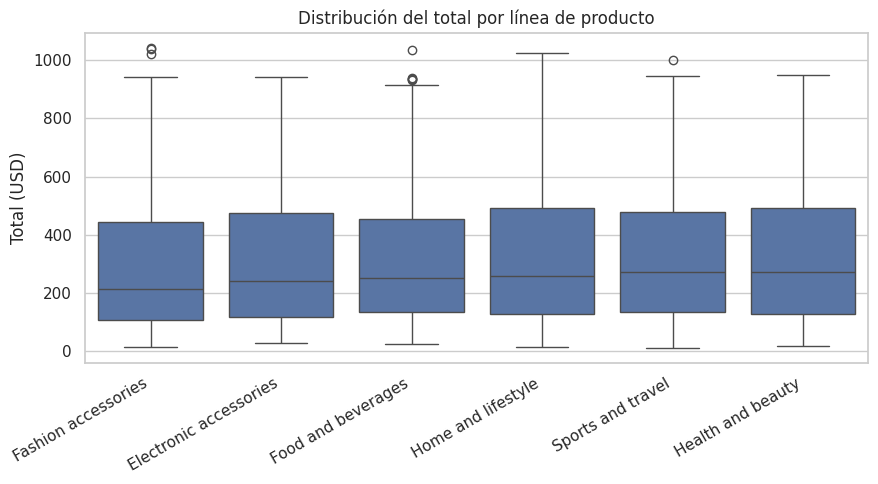

In [ ]:
figura, eje = plt.subplots(figsize=(9, 5))
orden = data.groupby('product_line')['total'].median().sort_values().index
sns.boxplot(data=data, x='product_line', y='total', order=orden, ax=eje)
eje.set_title('Distribución del total por línea de producto')
eje.set_xlabel('')
eje.set_ylabel('Total (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

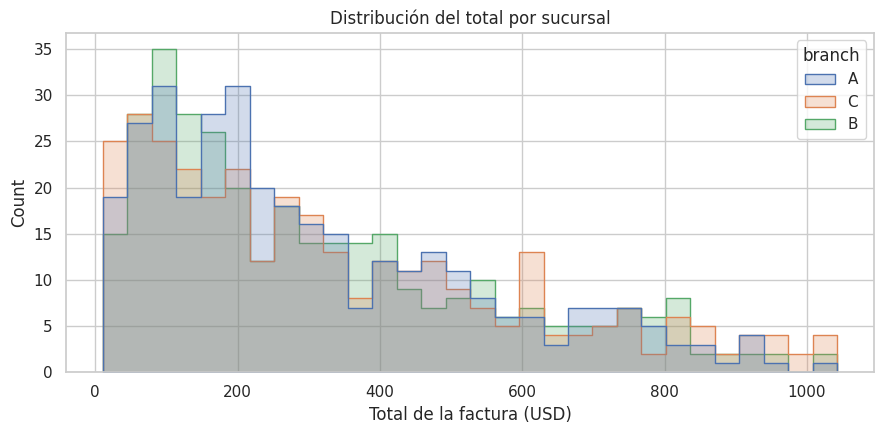

In [ ]:
figura, eje = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=data, x='total', hue='branch', bins=30, element='step', ax=eje)
eje.set_title('Distribución del total por sucursal')
eje.set_xlabel('Total de la factura (USD)')
plt.tight_layout()
plt.show()

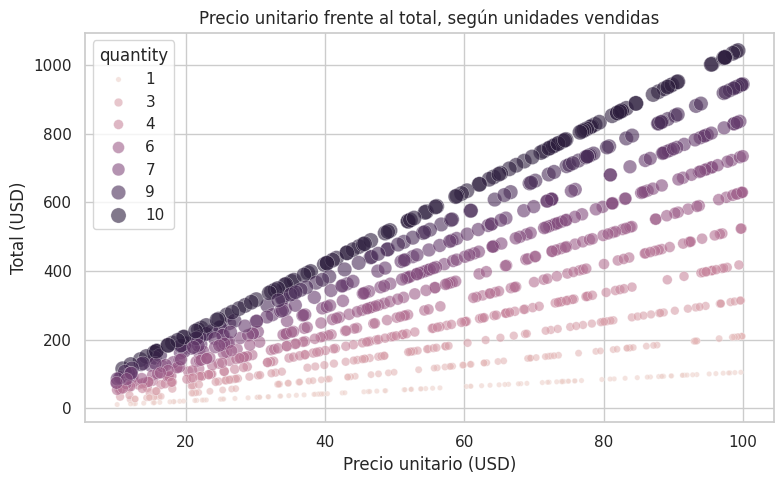

In [ ]:
figura, eje = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=data, x='unit_price', y='total', hue='quantity',
                size='quantity', sizes=(15, 120), alpha=0.6, ax=eje)
eje.set_title('Precio unitario frente al total, según unidades vendidas')
eje.set_xlabel('Precio unitario (USD)')
eje.set_ylabel('Total (USD)')
plt.tight_layout()
plt.show()

Ese último gráfico deja ver la estructura de los datos: el total no depende solo del precio, sino del producto entre precio y cantidad. Las bandas que se dibujan corresponden a cada valor de cantidad.

### Evolución en el tiempo con seaborn

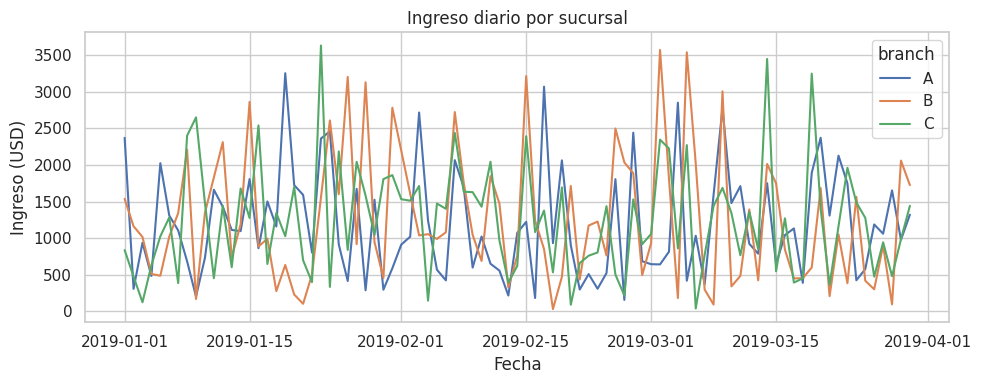

In [ ]:
ventas_dia = data.groupby(['date', 'branch'], as_index=False)['total'].sum()

figura, eje = plt.subplots(figsize=(10, 4))
sns.lineplot(data=ventas_dia, x='date', y='total', hue='branch', ax=eje)
eje.set_title('Ingreso diario por sucursal')
eje.set_xlabel('Fecha')
eje.set_ylabel('Ingreso (USD)')
plt.tight_layout()
plt.show()

### Mapa de calor

Sirve para dos cosas: mirar correlaciones entre variables numéricas y mostrar una tabla de doble entrada.

In [ ]:
numericas = data[['unit_price', 'quantity', 'total', 'gross_income', 'rating', 'hora']]
correlacion = numericas.corr().round(2)
correlacion

,unit_price,quantity,total,gross_income,rating,hora
unit_price,1.00,0.01,0.63,0.63,-0.01,0.01
quantity,0.01,1.00,0.71,0.71,-0.02,-0.01
total,0.63,0.71,1.00,1.00,-0.04,-0.00
gross_income,0.63,0.71,1.00,1.00,-0.04,-0.00
rating,-0.01,-0.02,-0.04,-0.04,1.00,-0.03
hora,0.01,-0.01,-0.00,-0.00,-0.03,1.00


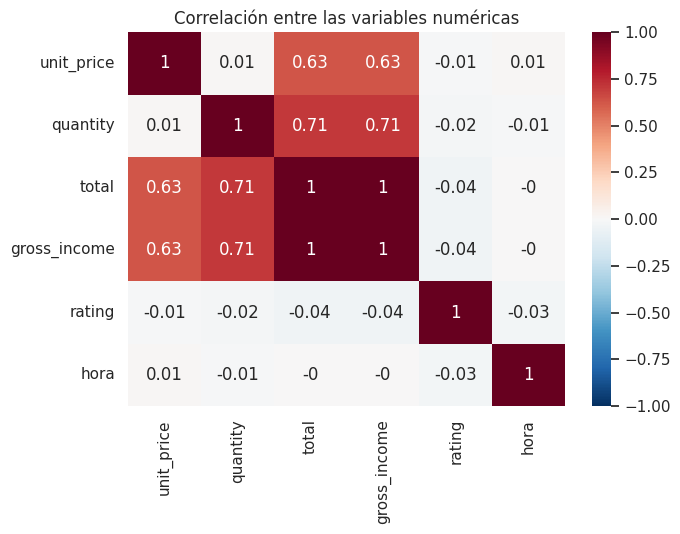

In [ ]:
figura, eje = plt.subplots(figsize=(7, 5.5))
sns.heatmap(correlacion, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=eje)
eje.set_title('Correlación entre las variables numéricas')
plt.tight_layout()
plt.show()

Dos lecturas del mapa. La correlación perfecta entre total y gross_income no es un hallazgo: el ingreso bruto es un porcentaje fijo del total en este conjunto. Y la calificación no se correlaciona con nada, que era lo que ya había mostrado el gráfico de dispersión.

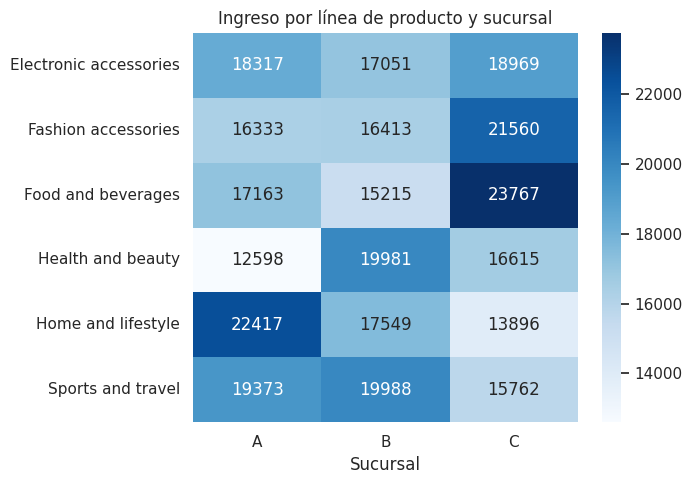

In [ ]:
# El mismo mapa sobre una tabla dinámica
tabla = data.pivot_table(index='product_line', columns='branch',
                         values='total', aggfunc='sum', fill_value=0)

figura, eje = plt.subplots(figsize=(7, 5))
sns.heatmap(tabla.round(0), annot=True, fmt='.0f', cmap='Blues', ax=eje)
eje.set_title('Ingreso por línea de producto y sucursal')
eje.set_xlabel('Sucursal')
eje.set_ylabel('')
plt.tight_layout()
plt.show()

## GRÁFICOS QUE ENGAÑAN

Un gráfico puede ser técnicamente correcto y aun así llevar a una conclusión falsa. Estos tres casos son los más frecuentes.

### El eje truncado

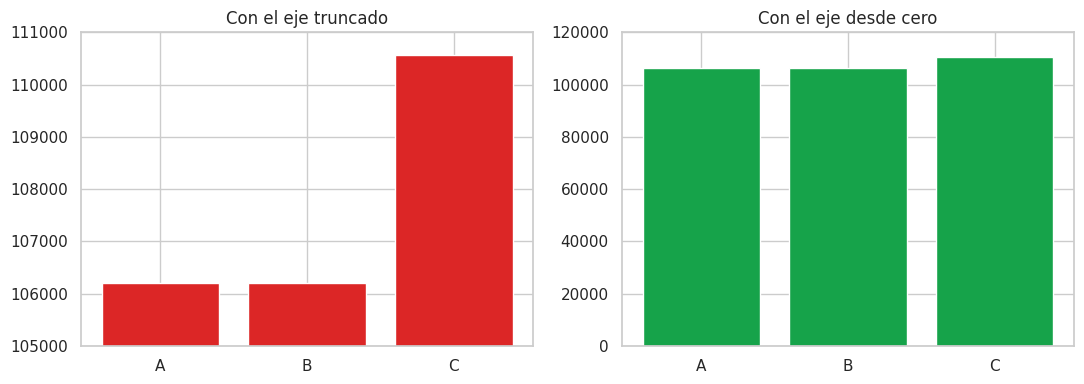

In [ ]:
figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].bar(ingreso_sucursal.index, ingreso_sucursal.values, color='#DC2626')
ejes[0].set_ylim(105000, 111000)
ejes[0].set_title('Con el eje truncado')

ejes[1].bar(ingreso_sucursal.index, ingreso_sucursal.values, color='#16A34A')
ejes[1].set_ylim(0, 120000)
ejes[1].set_title('Con el eje desde cero')

plt.tight_layout()
plt.show()

In [ ]:
# La diferencia real entre la sucursal mayor y la menor
round(ingreso_sucursal.max() - ingreso_sucursal.min(), 2)

4371.03

Los dos gráficos usan los mismos números. El de la izquierda sugiere que una sucursal triplica a otra; el de la derecha muestra que son prácticamente iguales. En barras el eje empieza en cero, sin excepciones.

### La torta con demasiadas porciones

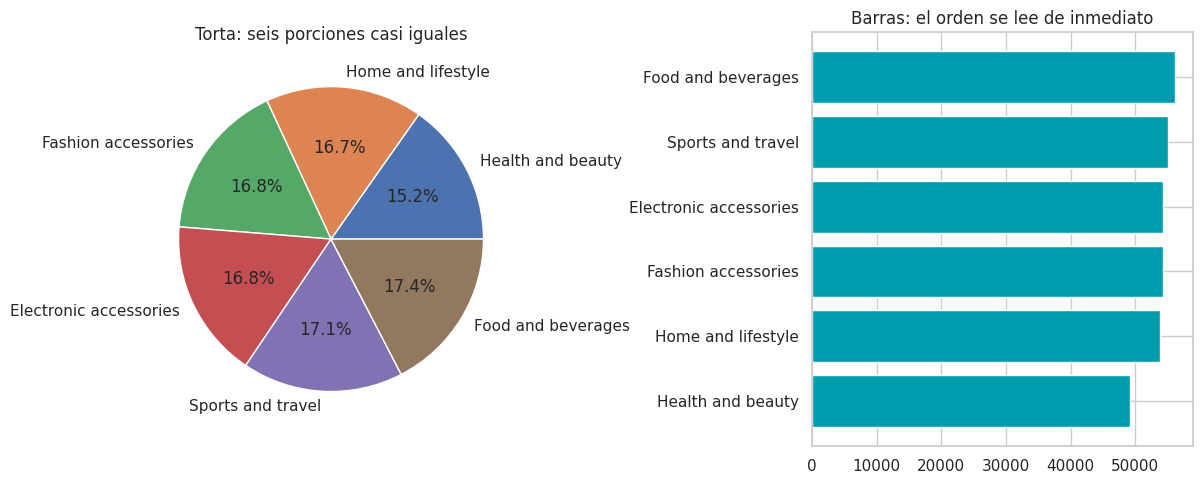

In [ ]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].pie(ingreso_linea.values, labels=ingreso_linea.index, autopct='%1.1f%%')
ejes[0].set_title('Torta: seis porciones casi iguales')

ejes[1].barh(ingreso_linea.index, ingreso_linea.values, color='#009DAE')
ejes[1].set_title('Barras: el orden se lee de inmediato')

plt.tight_layout()
plt.show()

El ojo humano compara longitudes mucho mejor que ángulos. Con seis categorías de tamaño parecido, la torta no permite ordenarlas; las barras sí.

### El exceso de decoración

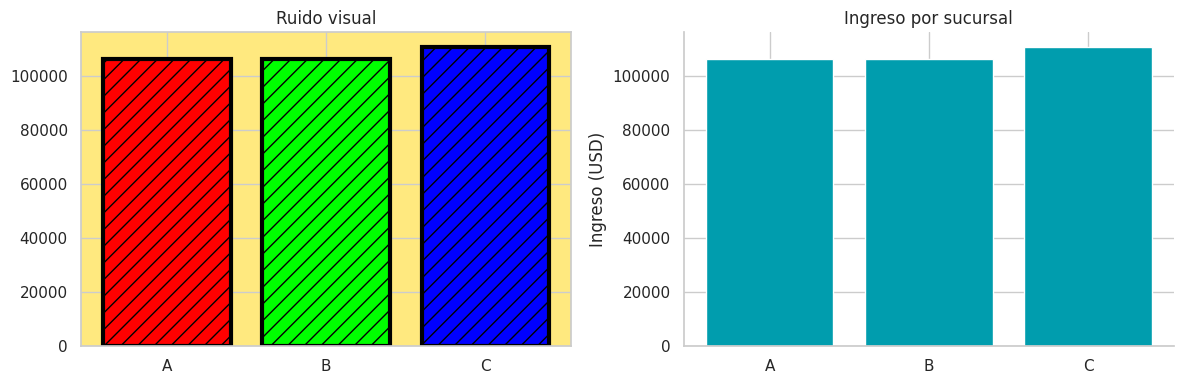

In [ ]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].bar(ingreso_sucursal.index, ingreso_sucursal.values,
            color=['#FF0000', '#00FF00', '#0000FF'], edgecolor='black', linewidth=3, hatch='//')
ejes[0].set_facecolor('#FFE97F')
ejes[0].set_title('Ruido visual')

ejes[1].bar(ingreso_sucursal.index, ingreso_sucursal.values, color='#009DAE')
ejes[1].set_title('Ingreso por sucursal')
ejes[1].set_ylabel('Ingreso (USD)')
ejes[1].spines['top'].set_visible(False)
ejes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Cada elemento que no aporta información compite con la que sí aporta. Un color por categoría cuando la categoría ya está rotulada en el eje es información repetida.

## CIERRE

### El gráfico final del análisis

Una figura pensada para un informe: responde una pregunta, está ordenada, tiene rótulos y se guarda en archivo.

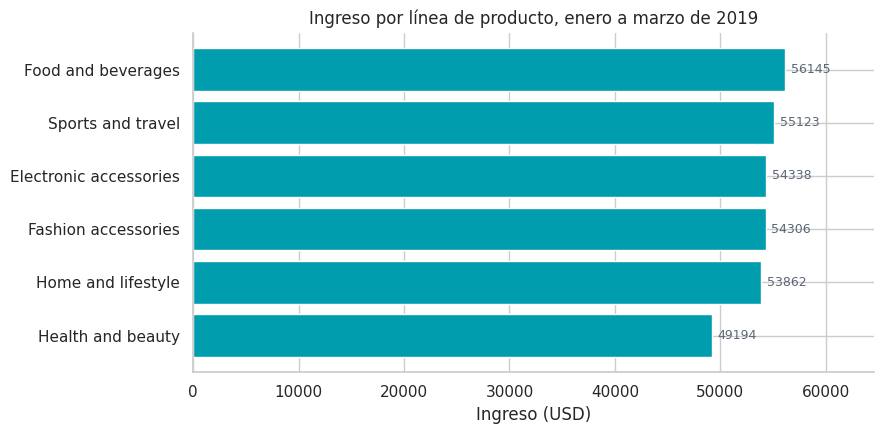

In [ ]:
resumen = (
    data
    .groupby('product_line', as_index=False)
    .agg(ingreso=('total', 'sum'), facturas=('invoice_id', 'size'))
    .sort_values('ingreso')
)

figura, eje = plt.subplots(figsize=(9, 4.5))
barras = eje.barh(resumen['product_line'], resumen['ingreso'], color='#009DAE')
eje.bar_label(barras, fmt='%.0f', padding=4, fontsize=9, color='#5B6577')
eje.set_title('Ingreso por línea de producto, enero a marzo de 2019')
eje.set_xlabel('Ingreso (USD)')
eje.set_xlim(0, resumen['ingreso'].max() * 1.15)
eje.spines['top'].set_visible(False)
eje.spines['right'].set_visible(False)
plt.tight_layout()
figura.savefig('ingreso_por_linea.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# El hallazgo, escrito en una frase
diferencia = resumen['ingreso'].max() - resumen['ingreso'].min()
print(resumen.iloc[-1]['product_line'])
print(round(diferencia, 2))

Food and beverages
6951.1


Food and beverages encabeza el ingreso del período, pero la diferencia con la última línea es de unos 7000 dólares sobre un total de 323000, es decir un 2 %. La conclusión no es que haya una línea ganadora, sino que el portafolio está muy parejo y ninguna línea explica el resultado por sí sola.

Esa frase es el producto del análisis. El gráfico solo la hace visible.

### Lista de verificación antes de entregar un gráfico

* ¿Qué pregunta responde? Si no hay pregunta, sobra el gráfico.
* ¿El tipo de gráfico corresponde a esa pregunta?
* ¿Tiene título y nombres de ejes con unidades?
* ¿Las categorías están ordenadas por valor y no alfabéticamente?
* ¿El eje de una barra empieza en cero?
* ¿Se puede quitar algún elemento sin perder información?
* ¿Hay una frase escrita que diga qué se concluye?